In [12]:
"""
Day 2: SMA Crossover Backtest - CORRECTED VERSION
Goal: Understand proper returns calculation
"""

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Imports successful!")


✅ Imports successful!


In [13]:
# Download BTC data
ticker = 'BTC-USD'
start_date = '2020-01-01'
end_date = '2024-12-31'

print(f"Downloading {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Downloaded {len(df)} days")
df.head()

✅ Downloaded 1826 days


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [14]:
# Calculate Simple Moving Averages
short_window = 50
long_window = 200

df['SMA_50'] = df['Close'].rolling(window=short_window).mean()
df['SMA_200'] = df['Close'].rolling(window=long_window).mean()

print(f"✅ Calculated SMAs")
df[['Close', 'SMA_50', 'SMA_200']].tail(10)

✅ Calculated SMAs


Price,Close,SMA_50,SMA_200
Ticker,BTC-USD,,
Date,,,
2024-12-21,97224.726562,92407.335156,70200.753594
2024-12-22,95104.937500,92923.648438,70320.864180
2024-12-23,94686.242188,93442.550937,70440.509570
2024-12-24,98676.093750,94059.842656,70587.177109
2024-12-25,99299.195312,94658.635313,70737.144219
2024-12-26,95795.515625,95061.764063,70867.881836
2024-12-27,94164.859375,95426.964063,70991.144727
2024-12-28,95163.929688,95799.333125,71130.304219


In [15]:
# Generate trading signals
df['Signal'] = np.where(df['SMA_50'] > df['SMA_200'], 1, 0)
df['Position'] = df['Signal'].shift(1)

print(f"✅ Generated signals")
df[['Close', 'SMA_50', 'SMA_200', 'Signal', 'Position']].tail(10)

✅ Generated signals


Price,Close,SMA_50,SMA_200,Signal,Position
Ticker,BTC-USD,,,,
Date,,,,,
2024-12-21,97224.726562,92407.335156,70200.753594,1,1.0
2024-12-22,95104.937500,92923.648438,70320.864180,1,1.0
2024-12-23,94686.242188,93442.550937,70440.509570,1,1.0
2024-12-24,98676.093750,94059.842656,70587.177109,1,1.0
2024-12-25,99299.195312,94658.635313,70737.144219,1,1.0
2024-12-26,95795.515625,95061.764063,70867.881836,1,1.0
2024-12-27,94164.859375,95426.964063,70991.144727,1,1.0
2024-12-28,95163.929688,95799.333125,71130.304219,1,1.0


In [16]:
# Calculate daily returns
df['Market_Returns'] = df['Close'].pct_change()

print(f"✅ Calculated daily returns")
df[['Close', 'Market_Returns']].tail(10)

✅ Calculated daily returns


Price,Close,Market_Returns
Ticker,BTC-USD,
Date,,
2024-12-21,97224.726562,-0.005434
2024-12-22,95104.937500,-0.021803
2024-12-23,94686.242188,-0.004402
2024-12-24,98676.093750,0.042138
2024-12-25,99299.195312,0.006315
2024-12-26,95795.515625,-0.035284
2024-12-27,94164.859375,-0.017022
2024-12-28,95163.929688,0.010610


In [17]:
# Calculate cumulative market returns (buy & hold)
df['Cumulative_Market'] = (1 + df['Market_Returns']).cumprod()

print(f"✅ Calculated cumulative market returns")
df[['Close', 'Market_Returns', 'Cumulative_Market']].tail(10)

✅ Calculated cumulative market returns


Price,Close,Market_Returns,Cumulative_Market
Ticker,BTC-USD,,
Date,,,
2024-12-21,97224.726562,-0.005434,13.503107
2024-12-22,95104.937500,-0.021803,13.208699
2024-12-23,94686.242188,-0.004402,13.150549
2024-12-24,98676.093750,0.042138,13.704681
2024-12-25,99299.195312,0.006315,13.791221
2024-12-26,95795.515625,-0.035284,13.304611
2024-12-27,94164.859375,-0.017022,13.078136
2024-12-28,95163.929688,0.010610,13.216892


In [18]:
# Calculate strategy returns (Position × DAILY returns)
df['Strategy_Returns'] = df['Position'] * df['Market_Returns']

print(f"✅ Calculated strategy returns")
df[['Position', 'Market_Returns', 'Strategy_Returns']].tail(10)

✅ Calculated strategy returns


Price,Position,Market_Returns,Strategy_Returns
Ticker,,,
Date,,,
2024-12-21,1.0,-0.005434,-0.005434
2024-12-22,1.0,-0.021803,-0.021803
2024-12-23,1.0,-0.004402,-0.004402
2024-12-24,1.0,0.042138,0.042138
2024-12-25,1.0,0.006315,0.006315
2024-12-26,1.0,-0.035284,-0.035284
2024-12-27,1.0,-0.017022,-0.017022
2024-12-28,1.0,0.010610,0.010610


In [19]:
# Calculate cumulative strategy returns
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns']).cumprod()

print(f"✅ Calculated cumulative strategy returns")
df[['Cumulative_Market', 'Cumulative_Strategy']].tail(10)

✅ Calculated cumulative strategy returns


Price,Cumulative_Market,Cumulative_Strategy
Ticker,,
Date,,
2024-12-21,13.503107,9.490108
2024-12-22,13.208699,9.283196
2024-12-23,13.150549,9.242327
2024-12-24,13.704681,9.631776
2024-12-25,13.791221,9.692597
2024-12-26,13.304611,9.350603
2024-12-27,13.078136,9.191435
2024-12-28,13.216892,9.288954


In [21]:
# Remove NaN values
df_clean = df.dropna()

print(f"✅ Cleaned data: {len(df_clean)} rows (removed {len(df) - len(df_clean)} NaN rows)")
print(f"\nFinal Results:")
print(f"Buy & Hold: {df_clean['Cumulative_Market'].iloc[-1]:.2f}x")
print(f"Strategy:   {df_clean['Cumulative_Strategy'].iloc[-1]:.2f}x")

✅ Cleaned data: 1627 rows (removed 199 NaN rows)

Final Results:
Buy & Hold: 12.87x
Strategy:   9.04x


In [23]:
# Calculate Sharpe Ratio
def calculate_sharpe(returns):
    mean_return = returns.mean()
    std_return = returns.std()
    if std_return == 0:
        return 0
    sharpe = (mean_return / std_return) * np.sqrt(252)
    return sharpe

sharpe_market = calculate_sharpe(df_clean['Market_Returns'])
sharpe_strategy = calculate_sharpe(df_clean['Strategy_Returns'])

print(f"Sharpe Ratio:")
print(f"Buy & Hold: {sharpe_market:.2f}")
print(f"Strategy:   {sharpe_strategy:.2f}")

Sharpe Ratio:
Buy & Hold: 0.96
Strategy:   1.04


In [25]:
# Calculate Maximum Drawdown
def calculate_max_drawdown(cumulative_returns):
    """
    Max Drawdown = Worst peak-to-trough decline
    Example: Portfolio goes from $100 to $120, then drops to $80
    Drawdown = (80 - 120) / 120 = -33.3%
    """
    
    # Step 1: Track the highest value seen so far at each point in time
    # Example: [1.0, 1.2, 1.5, 1.3, 1.8] → [1.0, 1.2, 1.5, 1.5, 1.8]
    running_max = cumulative_returns.cummax()
    
    # Step 2: Calculate how far we are from the peak at each point
    # (Current Value - Peak) / Peak
    # Negative = we're below the peak (in drawdown)
    # Zero = we're at a new peak (no drawdown)
    drawdown = (cumulative_returns - running_max) / running_max
    
    # Step 3: Find the WORST drawdown (most negative value)
    # Example: [-0.05, 0, -0.10, -0.33, 0] → min = -0.33
    max_dd = drawdown.min() * 100  # Convert to percentage
    
    return max_dd

# Calculate for both strategies
max_dd_market = calculate_max_drawdown(df_clean['Cumulative_Market'])
max_dd_strategy = calculate_max_drawdown(df_clean['Cumulative_Strategy'])

print(f"Maximum Drawdown:")
print(f"Buy & Hold: {max_dd_market:.2f}%")
print(f"Strategy:   {max_dd_strategy:.2f}%")

Maximum Drawdown:
Buy & Hold: -76.63%
Strategy:   -56.46%


✅ Chart saved!


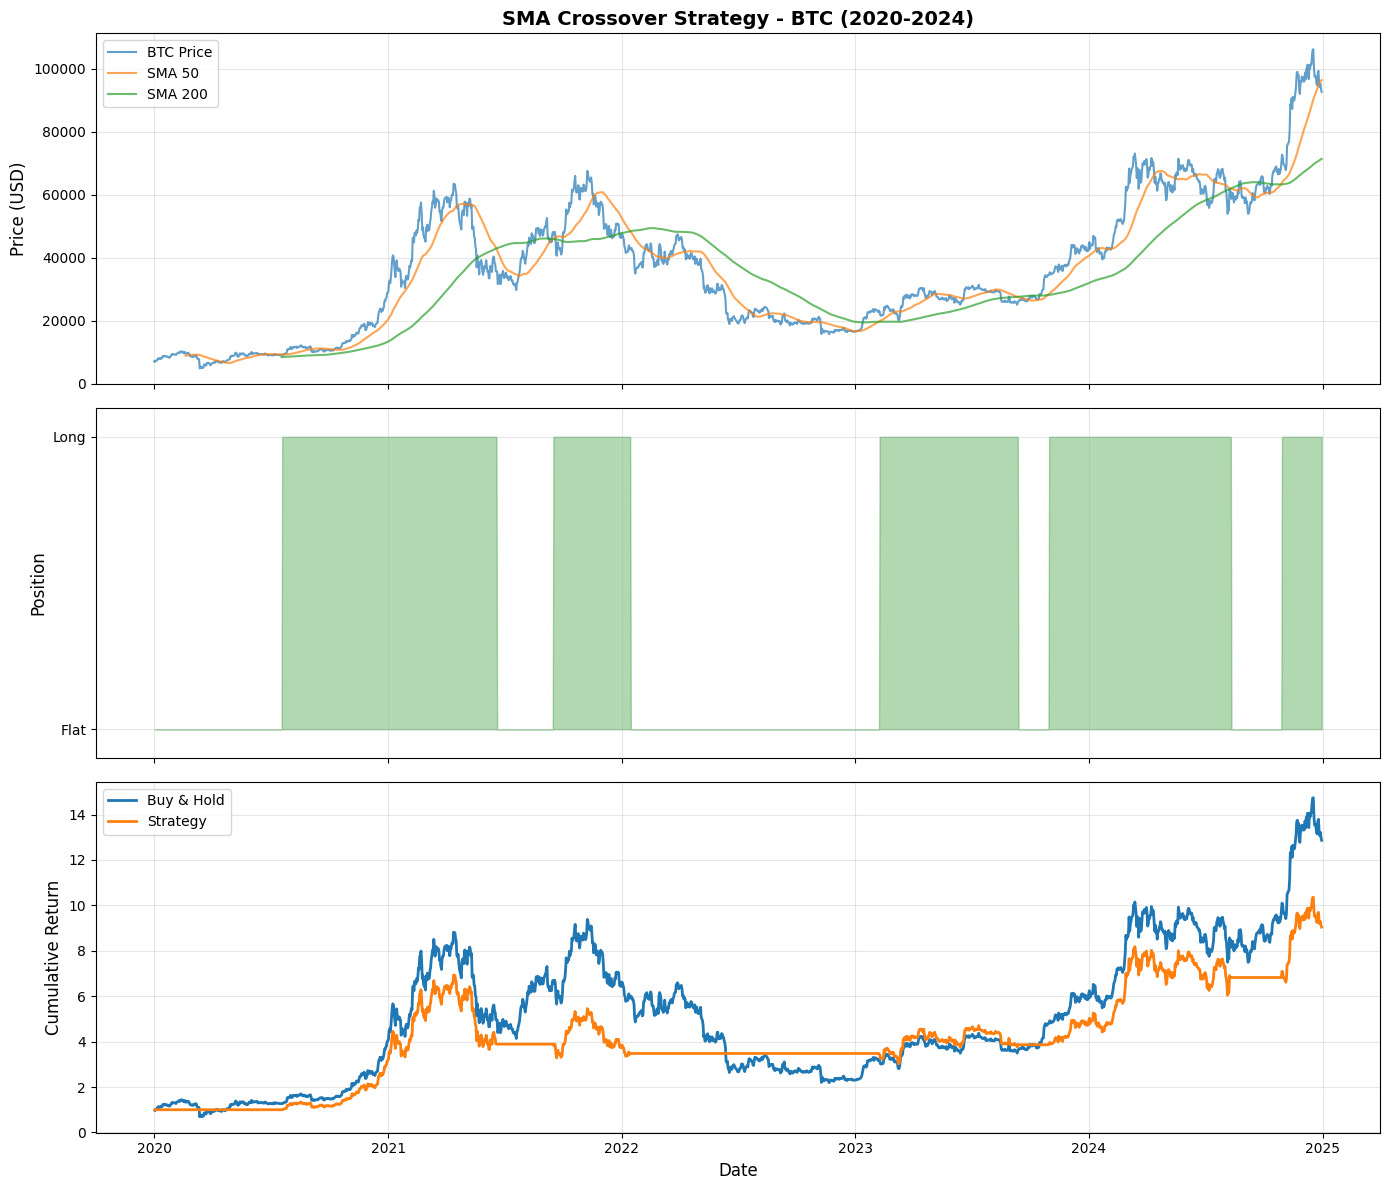

In [26]:
# Create 3-panel chart
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price and SMAs
ax1.plot(df.index, df['Close'], label='BTC Price', alpha=0.7, linewidth=1.5)
ax1.plot(df.index, df['SMA_50'], label='SMA 50', alpha=0.7, linewidth=1.5)
ax1.plot(df.index, df['SMA_200'], label='SMA 200', alpha=0.7, linewidth=1.5)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.set_title('SMA Crossover Strategy - BTC (2020-2024)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Panel 2: Position (when we're in the market)
ax2.fill_between(df.index, 0, df['Position'], alpha=0.3, color='green')
ax2.set_ylabel('Position', fontsize=12)
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Flat', 'Long'])
ax2.grid(alpha=0.3)

# Panel 3: Cumulative Returns
ax3.plot(df.index, df['Cumulative_Market'], label='Buy & Hold', linewidth=2)
ax3.plot(df.index, df['Cumulative_Strategy'], label='Strategy', linewidth=2)
ax3.set_ylabel('Cumulative Return', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sma_backtest_results.png', dpi=300)
print("✅ Chart saved!")
plt.show()
